In [1]:
# Importiamo le librerie necessarie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Carichiamo il dataset
df = pd.read_excel('../data/Volve production data.xlsx')

# Filtriamo il pozzo F-14 H e ordiniamo per data
pozzo = 'NO 15/9-F-14 H'
df_pozzo = df[df['WELL_BORE_CODE'] == pozzo].copy()
df_pozzo = df_pozzo.sort_values('DATEPRD').reset_index(drop=True)

# Teniamo solo i giorni in cui il pozzo era in produzione (olio > 0)
df_prod = df_pozzo[df_pozzo['BORE_OIL_VOL'] > 0].copy()
df_prod = df_prod.reset_index(drop=True)

# Creiamo una colonna "giorni dall'inizio produzione"
df_prod['DAYS'] = (df_prod['DATEPRD'] - df_prod['DATEPRD'].min()).dt.days

print(f"Giorni totali in produzione: {len(df_prod)}")
print(f"Dal: {df_prod['DATEPRD'].min().date()}")
print(f"Al: {df_prod['DATEPRD'].max().date()}")
print(f"Portata iniziale: {df_prod['BORE_OIL_VOL'].iloc[0]:.0f} Sm³/giorno")
print(f"Portata finale: {df_prod['BORE_OIL_VOL'].iloc[-1]:.0f} Sm³/giorno")

Giorni totali in produzione: 2723
Dal: 2008-07-13
Al: 2016-07-13
Portata iniziale: 1735 Sm³/giorno
Portata finale: 68 Sm³/giorno


In [2]:
# ── MODELLI DI ARPS ──────────────────────────────────────────────────────────

# 1. Decline ESPONENZIALE: q(t) = qi * exp(-Di * t)
def arps_esponenziale(t, qi, Di):
    return qi * np.exp(-Di * t)

# 2. Decline IPERBOLICA: q(t) = qi / (1 + b*Di*t)^(1/b)
def arps_iperbolica(t, qi, Di, b):
    return qi / (1 + b * Di * t) ** (1/b)

# 3. Decline ARMONICA: caso speciale iperbolica con b=1
def arps_armonica(t, qi, Di):
    return qi / (1 + Di * t)

# ── FITTING SUI DATI REALI ────────────────────────────────────────────────────
t = df_prod['DAYS'].values
q = df_prod['BORE_OIL_VOL'].values

# Fitting esponenziale
p_esp, _ = curve_fit(arps_esponenziale, t, q, 
                     p0=[1500, 0.001], maxfev=5000)

# Fitting iperbolico
p_iper, _ = curve_fit(arps_iperbolica, t, q, 
                      p0=[1500, 0.001, 0.5], 
                      bounds=([0, 0, 0], [10000, 1, 2]),
                      maxfev=5000)

# Fitting armonico
p_arm, _ = curve_fit(arps_armonica, t, q, 
                     p0=[1500, 0.001], maxfev=5000)

print("── Parametri fitting ──")
print(f"Esponenziale: qi={p_esp[0]:.0f} Sm³/g, Di={p_esp[1]:.5f} /giorno")
print(f"Iperbolico:   qi={p_iper[0]:.0f} Sm³/g, Di={p_iper[1]:.5f} /giorno, b={p_iper[2]:.3f}")
print(f"Armonico:     qi={p_arm[0]:.0f} Sm³/g, Di={p_arm[1]:.5f} /giorno")

── Parametri fitting ──
Esponenziale: qi=4381 Sm³/g, Di=0.00094 /giorno
Iperbolico:   qi=4380 Sm³/g, Di=0.00094 /giorno, b=0.000
Armonico:     qi=4854 Sm³/g, Di=0.00208 /giorno


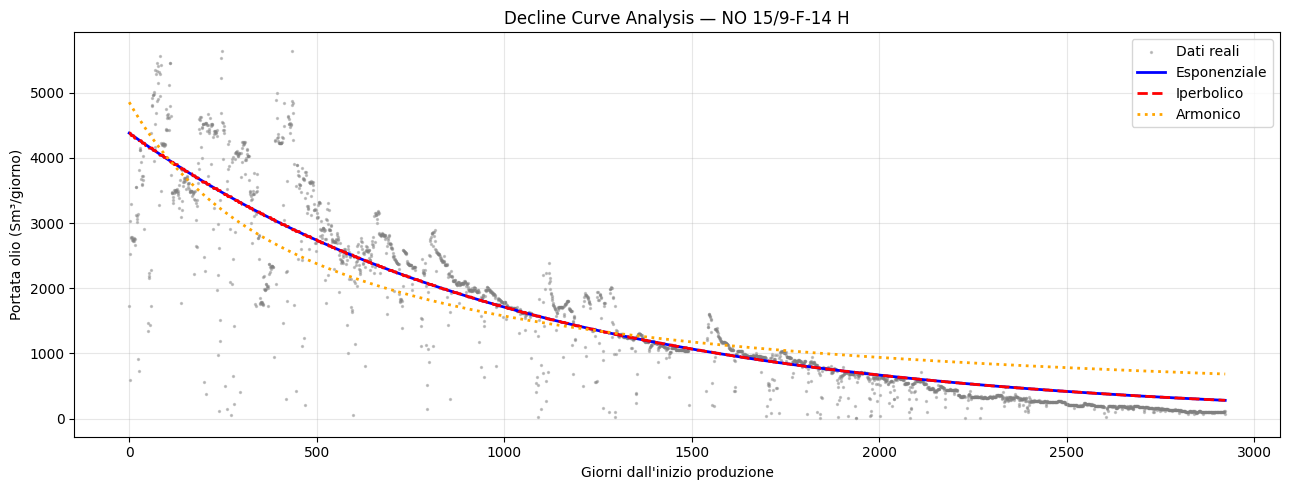

In [3]:
# ── VISUALIZZAZIONE FITTING ───────────────────────────────────────────────────

# Creiamo una linea temporale continua per il plot
t_plot = np.linspace(0, t.max(), 1000)

# Calcoliamo le curve dei tre modelli
q_esp  = arps_esponenziale(t_plot, *p_esp)
q_iper = arps_iperbolica(t_plot, *p_iper)
q_arm  = arps_armonica(t_plot, *p_arm)

plt.figure(figsize=(13, 5))

# Dati reali
plt.scatter(t, q, color='gray', s=2, alpha=0.4, label='Dati reali')

# Modelli
plt.plot(t_plot, q_esp,  color='blue',   linewidth=2, label='Esponenziale')
plt.plot(t_plot, q_iper, color='red',    linewidth=2, linestyle='--', label='Iperbolico')
plt.plot(t_plot, q_arm,  color='orange', linewidth=2, linestyle=':', label='Armonico')

plt.title(f'Decline Curve Analysis — {pozzo}')
plt.xlabel('Giorni dall\'inizio produzione')
plt.ylabel('Portata olio (Sm³/giorno)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# ── METRICHE DI ERRORE ────────────────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calcoliamo le previsioni sui dati reali
q_esp_pred  = arps_esponenziale(t, *p_esp)
q_iper_pred = arps_iperbolica(t, *p_iper)
q_arm_pred  = arps_armonica(t, *p_arm)

def metriche(nome, q_reale, q_pred):
    rmse = np.sqrt(mean_squared_error(q_reale, q_pred))
    mae  = mean_absolute_error(q_reale, q_pred)
    mape = np.mean(np.abs((q_reale - q_pred) / q_reale)) * 100
    r2   = 1 - np.sum((q_reale - q_pred)**2) / np.sum((q_reale - q_reale.mean())**2)
    print(f"{nome:15} | RMSE: {rmse:7.0f} | MAE: {mae:7.0f} | MAPE: {mape:6.1f}% | R²: {r2:.3f}")

print(f"{'Modello':15} | {'RMSE':>7} | {'MAE':>7} | {'MAPE':>8} | R²")
print("-" * 60)
metriche("Esponenziale",  q, q_esp_pred)
metriche("Iperbolico",    q, q_iper_pred)
metriche("Armonico",      q, q_arm_pred)

Modello         |    RMSE |     MAE |     MAPE | R²
------------------------------------------------------------
Esponenziale    | RMSE:     533 | MAE:     317 | MAPE:   86.3% | R²: 0.829
Iperbolico      | RMSE:     532 | MAE:     317 | MAPE:   86.4% | R²: 0.829
Armonico        | RMSE:     664 | MAE:     508 | MAPE:  161.0% | R²: 0.735


In [5]:
# ── EUR - Estimated Ultimate Recovery ─────────────────────────────────────────
# Integriamo le curve fino al limite economico (q_limite = 50 Sm³/giorno)

q_limite = 50  # Sm³/giorno - sotto questo valore il pozzo non è economico

def calcola_eur(modello, params, t_start=0, q_lim=50, dt=1):
    """Integra la curva di produzione fino al limite economico"""
    t_fine = t_start
    q_attuale = modello(t_fine, *params)
    eur = 0
    while q_attuale > q_lim and t_fine < 10000:
        eur += q_attuale * dt
        t_fine += dt
        q_attuale = modello(t_fine, *params)
    return eur / 1e6  # Convertiamo in milioni di Sm³

eur_esp  = calcola_eur(arps_esponenziale, p_esp)
eur_iper = calcola_eur(arps_iperbolica, p_iper)
eur_arm  = calcola_eur(arps_armonica, p_arm)

# Produzione cumulativa reale
prod_cumulativa_reale = df_prod['BORE_OIL_VOL'].sum() / 1e6

print("── EUR stimato dai modelli ──")
print(f"Produzione reale cumulativa: {prod_cumulativa_reale:.3f} M Sm³")
print(f"EUR Esponenziale:            {eur_esp:.3f} M Sm³")
print(f"EUR Iperbolico:              {eur_iper:.3f} M Sm³")
print(f"EUR Armonico:                {eur_arm:.3f} M Sm³")

── EUR stimato dai modelli ──
Produzione reale cumulativa: 3.942 M Sm³
EUR Esponenziale:            4.606 M Sm³
EUR Iperbolico:              4.606 M Sm³
EUR Armonico:                7.184 M Sm³


In [6]:
# ── PREPROCESSING PER XGBOOST ─────────────────────────────────────────────────
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Lavoriamo sul pozzo F-14 H già caricato
df_ml = df_prod[['DATEPRD', 'DAYS', 'BORE_OIL_VOL', 
                  'BORE_GAS_VOL', 'BORE_WAT_VOL',
                  'AVG_DOWNHOLE_PRESSURE', 'AVG_CHOKE_SIZE_P',
                  'ON_STREAM_HRS']].copy()

# Gestiamo i valori mancanti con interpolazione lineare
df_ml = df_ml.interpolate(method='linear').bfill()
# Creiamo feature ingegneristiche
df_ml['GOR']          = df_ml['BORE_GAS_VOL'] / df_ml['BORE_OIL_VOL'].replace(0, np.nan)
df_ml['WATERCUT']     = df_ml['BORE_WAT_VOL'] / (df_ml['BORE_OIL_VOL'] + df_ml['BORE_WAT_VOL']).replace(0, np.nan)
df_ml['OIL_ROLL7']    = df_ml['BORE_OIL_VOL'].rolling(7).mean()   # media mobile 7 giorni
df_ml['OIL_ROLL30']   = df_ml['BORE_OIL_VOL'].rolling(30).mean()  # media mobile 30 giorni
df_ml['OIL_CUMSUM']   = df_ml['BORE_OIL_VOL'].cumsum()            # produzione cumulativa
df_ml['OIL_LAG1']     = df_ml['BORE_OIL_VOL'].shift(1)            # produzione giorno precedente
df_ml['OIL_LAG7']     = df_ml['BORE_OIL_VOL'].shift(7)            # produzione 7 giorni fa

# Rimuoviamo le righe con NaN create dalle rolling windows
df_ml = df_ml.dropna().reset_index(drop=True)

print(f"Righe dopo preprocessing: {len(df_ml)}")
print(f"\nFeature create:")
for col in df_ml.columns:
    print(f"  {col}")

Righe dopo preprocessing: 2694

Feature create:
  DATEPRD
  DAYS
  BORE_OIL_VOL
  BORE_GAS_VOL
  BORE_WAT_VOL
  AVG_DOWNHOLE_PRESSURE
  AVG_CHOKE_SIZE_P
  ON_STREAM_HRS
  GOR
  WATERCUT
  OIL_ROLL7
  OIL_ROLL30
  OIL_CUMSUM
  OIL_LAG1
  OIL_LAG7


In [7]:
# ── TRAIN/TEST SPLIT E TRAINING XGBOOST ──────────────────────────────────────

# Feature usate dal modello (escludiamo la target e la data)
features = ['DAYS', 'BORE_GAS_VOL', 'BORE_WAT_VOL', 'AVG_DOWNHOLE_PRESSURE',
            'AVG_CHOKE_SIZE_P', 'ON_STREAM_HRS', 'GOR', 'WATERCUT',
            'OIL_ROLL7', 'OIL_ROLL30', 'OIL_CUMSUM', 'OIL_LAG1', 'OIL_LAG7']

target = 'BORE_OIL_VOL'

# Split temporale: 80% train, 20% test
# IMPORTANTE: non shuffliamo — i dati temporali devono restare in ordine
split = int(len(df_ml) * 0.8)
train = df_ml.iloc[:split]
test  = df_ml.iloc[split:]

X_train = train[features]
y_train = train[target]
X_test  = test[features]
y_test  = test[target]

print(f"Train: {len(train)} giorni ({train['DATEPRD'].min().date()} → {train['DATEPRD'].max().date()})")
print(f"Test:  {len(test)} giorni ({test['DATEPRD'].min().date()} → {test['DATEPRD'].max().date()})")

# Training XGBoost
modelo_xgb = XGBRegressor(
    n_estimators=500,      # numero di alberi
    max_depth=4,           # profondità massima di ogni albero
    learning_rate=0.05,    # passo di apprendimento
    subsample=0.8,         # frazione di dati usata per ogni albero
    random_state=42
)

modelo_xgb.fit(X_train, y_train)
print("\nTraining completato!")

# Previsioni
y_pred_train = modelo_xgb.predict(X_train)
y_pred_test  = modelo_xgb.predict(X_test)

# Metriche
def metriche_ml(nome, y_reale, y_pred):
    rmse = np.sqrt(mean_squared_error(y_reale, y_pred))
    mae  = mean_absolute_error(y_reale, y_pred)
    mape = np.mean(np.abs((y_reale - y_pred) / y_reale)) * 100
    r2   = 1 - np.sum((y_reale - y_pred)**2) / np.sum((y_reale - y_reale.mean())**2)
    print(f"{nome:10} | RMSE: {rmse:6.0f} | MAE: {mae:6.0f} | MAPE: {mape:5.1f}% | R²: {r2:.3f}")

print(f"\n{'Set':10} | {'RMSE':>6} | {'MAE':>6} | {'MAPE':>7} | R²")
print("-" * 55)
metriche_ml("Train", y_train, y_pred_train)
metriche_ml("Test",  y_test,  y_pred_test)

Train: 2155 giorni (2008-08-12 → 2015-01-17)
Test:  539 giorni (2015-01-18 → 2016-07-13)

Training completato!

Set        |   RMSE |    MAE |    MAPE | R²
-------------------------------------------------------
Train      | RMSE:      8 | MAE:      6 | MAPE:   0.8% | R²: 1.000
Test       | RMSE:     17 | MAE:     14 | MAPE:   9.7% | R²: 0.917


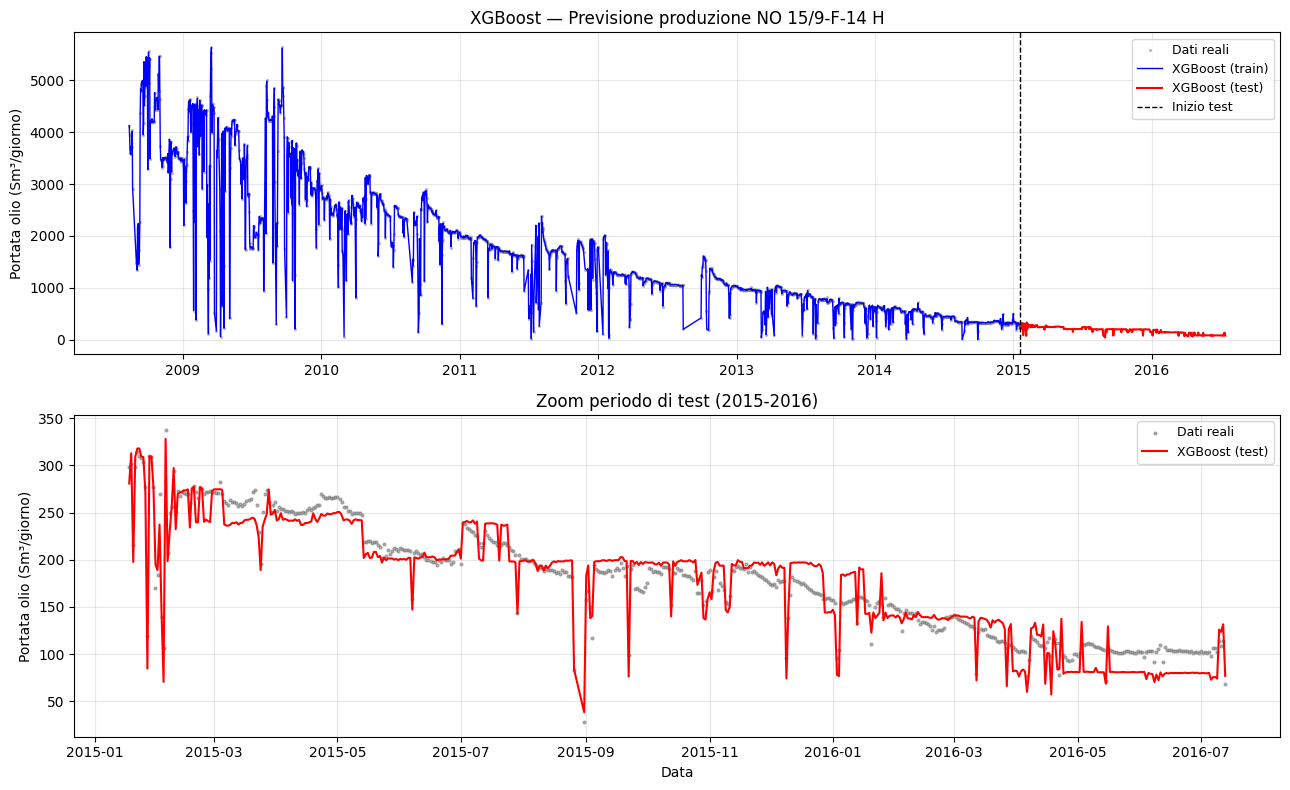

In [8]:
# ── VISUALIZZAZIONE PREVISIONI XGBOOST ───────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8))

# ── Grafico 1: Train + Test insieme ──
ax1.scatter(train['DATEPRD'], y_train, color='gray', s=2, alpha=0.4, label='Dati reali')
ax1.plot(train['DATEPRD'], y_pred_train, color='blue', linewidth=1, label='XGBoost (train)')
ax1.plot(test['DATEPRD'], y_pred_test, color='red', linewidth=1.5, label='XGBoost (test)')
ax1.axvline(test['DATEPRD'].min(), color='black', linestyle='--', linewidth=1, label='Inizio test')
ax1.set_title(f'XGBoost — Previsione produzione {pozzo}')
ax1.set_ylabel('Portata olio (Sm³/giorno)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── Grafico 2: Zoom sul periodo di test ──
ax2.scatter(test['DATEPRD'], y_test, color='gray', s=4, alpha=0.6, label='Dati reali')
ax2.plot(test['DATEPRD'], y_pred_test, color='red', linewidth=1.5, label='XGBoost (test)')
ax2.set_title('Zoom periodo di test (2015-2016)')
ax2.set_xlabel('Data')
ax2.set_ylabel('Portata olio (Sm³/giorno)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# ── CONFRONTO FINALE ARPS vs XGBOOST ─────────────────────────────────────────

# Arps sul periodo di test
t_test = test['DAYS'].values
q_esp_test  = arps_esponenziale(t_test, *p_esp)
q_iper_test = arps_iperbolica(t_test, *p_iper)

print("── Confronto su periodo di TEST ──")
print(f"\n{'Modello':15} | {'RMSE':>6} | {'MAE':>6} | {'MAPE':>7} | R²")
print("-" * 55)
metriche_ml("Esponenziale",  y_test.values, q_esp_test)
metriche_ml("Iperbolico",    y_test.values, q_iper_test)
metriche_ml("XGBoost",       y_test.values, y_pred_test)

── Confronto su periodo di TEST ──

Modello         |   RMSE |    MAE |    MAPE | R²
-------------------------------------------------------
Esponenziale | RMSE:    189 | MAE:    187 | MAPE: 121.3% | R²: -9.474
Iperbolico | RMSE:    189 | MAE:    187 | MAPE: 121.4% | R²: -9.487
XGBoost    | RMSE:     17 | MAE:     14 | MAPE:   9.7% | R²: 0.917


In [10]:
# ── PREPROCESSING PER LSTM ────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

# Selezioniamo le feature per l'LSTM
features_lstm = ['DAYS', 'BORE_GAS_VOL', 'BORE_WAT_VOL', 
                 'AVG_DOWNHOLE_PRESSURE', 'AVG_CHOKE_SIZE_P',
                 'ON_STREAM_HRS', 'GOR', 'WATERCUT',
                 'OIL_ROLL7', 'OIL_ROLL30', 'OIL_CUMSUM',
                 'OIL_LAG1', 'OIL_LAG7', 'BORE_OIL_VOL']

df_lstm = df_ml[features_lstm].copy()

# Normalizziamo tutti i dati tra 0 e 1
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_lstm)

# Creiamo sequenze temporali con finestra di 30 giorni
# L'LSTM guarda 30 giorni di storia per prevedere il giorno successivo
WINDOW = 30

X_lstm, y_lstm = [], []
for i in range(WINDOW, len(df_scaled)):
    X_lstm.append(df_scaled[i-WINDOW:i, :-1])  # 30 giorni di feature
    y_lstm.append(df_scaled[i, -1])             # target: produzione giorno i

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

# Split temporale 80/20
split = int(len(X_lstm) * 0.8)
X_train_l, X_test_l = X_lstm[:split], X_lstm[split:]
y_train_l, y_test_l = y_lstm[:split], y_lstm[split:]

print(f"Shape X_train: {X_train_l.shape}  → (campioni, giorni_finestra, feature)")
print(f"Shape X_test:  {X_test_l.shape}")

Shape X_train: (2131, 30, 13)  → (campioni, giorni_finestra, feature)
Shape X_test:  (533, 30, 13)


In [14]:
# ── ARCHITETTURA E TRAINING LSTM ─────────────────────────────────────────────
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# Seed fisso per riproducibilità
tf.random.set_seed(42)
np.random.seed(42)

# Costruiamo la rete
model = Sequential([
    Input(shape=(WINDOW, X_train_l.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# Early stopping con patience=50
early_stop = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

# Training
history = model.fit(
    X_train_l, y_train_l,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining completato!")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 30, 64)              │          19,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,929 (128.63 KB)

 Trainable params: 32,929 (128.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0348 - val_loss: 1.5289e-04
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0126 - val_loss: 4.0967e-04
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0117 - val_loss: 3.9214e-04
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0108 - val_loss: 1.1736e-04
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0106 - val_loss: 1.5766e-04
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0112 - val_loss: 3.2549e-04
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0097 - val_loss: 3.4907e-04
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0096 - val_loss: 2.8536e-04
Epoch 9/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0099 - val_loss: 5.9737e-04
Epoch 10/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0092 - val_loss: 9.8233e-04
Epoch 11/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0095 - val_loss: 0.0014
Epoch 12/100

In [15]:
# ── PREVISIONI LSTM E DE-NORMALIZZAZIONE ─────────────────────────────────────

# Previsioni in scala normalizzata
y_pred_train_l = model.predict(X_train_l, verbose=0)
y_pred_test_l  = model.predict(X_test_l, verbose=0)

# De-normalizziamo per tornare ai valori reali in Sm³/giorno
def denormalizza(y_scaled, scaler, n_features):
    dummy = np.zeros((len(y_scaled), n_features))
    dummy[:, -1] = y_scaled.flatten()
    return scaler.inverse_transform(dummy)[:, -1]

n_feat = len(features_lstm)
y_train_real      = denormalizza(y_train_l, scaler, n_feat)
y_test_real       = denormalizza(y_test_l, scaler, n_feat)
y_pred_train_real = denormalizza(y_pred_train_l, scaler, n_feat)
y_pred_test_real  = denormalizza(y_pred_test_l, scaler, n_feat)

# ── TABELLA COMPARATIVA FINALE ────────────────────────────────────────────────
print("══ CONFRONTO FINALE SU PERIODO DI TEST ══")
print(f"\n{'Modello':15} | {'RMSE':>6} | {'MAE':>6} | {'MAPE':>7} | R²")
print("-" * 55)
metriche_ml("Esponenziale",  y_test.values, q_esp_test)
metriche_ml("Iperbolico",    y_test.values, q_iper_test)
metriche_ml("XGBoost",       y_test.values, y_pred_test)
metriche_ml("LSTM",          y_test_real,   y_pred_test_real)

══ CONFRONTO FINALE SU PERIODO DI TEST ══

Modello         |   RMSE |    MAE |    MAPE | R²
-------------------------------------------------------
Esponenziale | RMSE:    189 | MAE:    187 | MAPE: 121.3% | R²: -9.474
Iperbolico | RMSE:    189 | MAE:    187 | MAPE: 121.4% | R²: -9.487
XGBoost    | RMSE:     17 | MAE:     14 | MAPE:   9.7% | R²: 0.917
LSTM       | RMSE:     29 | MAE:     21 | MAPE:  14.7% | R²: 0.736


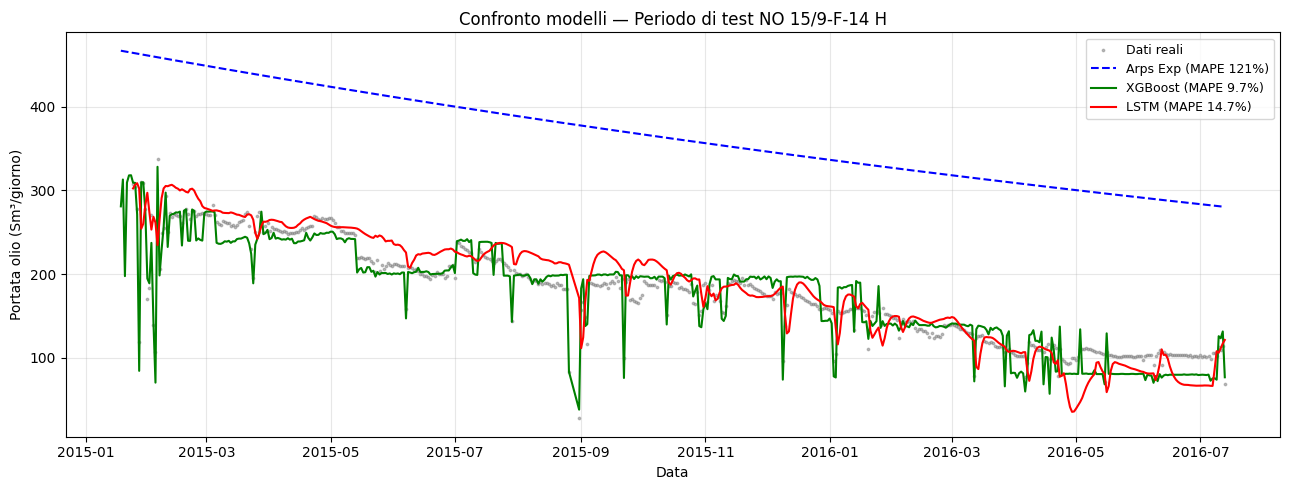

In [17]:
# ── GRAFICO COMPARATIVO FINALE ────────────────────────────────────────────────

# Date allineate al periodo LSTM (più corto per via della finestra)
date_test_lstm = df_ml.iloc[split + WINDOW:]['DATEPRD'].reset_index(drop=True)
date_test_xgb  = test['DATEPRD'].reset_index(drop=True)

plt.figure(figsize=(13, 5))
plt.scatter(date_test_lstm, y_test_real, color='gray', s=3, alpha=0.5, label='Dati reali')
plt.plot(date_test_xgb,  q_esp_test,       color='blue',  linewidth=1.5, linestyle='--', label='Arps Exp (MAPE 121%)')
plt.plot(date_test_xgb,  y_pred_test,      color='green', linewidth=1.5, label='XGBoost (MAPE 9.7%)')
plt.plot(date_test_lstm, y_pred_test_real, color='red',   linewidth=1.5, label='LSTM (MAPE 14.7%)')
plt.title(f'Confronto modelli — Periodo di test {pozzo}')
plt.xlabel('Data')
plt.ylabel('Portata olio (Sm³/giorno)')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show(

In [21]:
# ── SALVATAGGIO MODELLI ───────────────────────────────────────────────────────
import pickle
import os

os.makedirs('../models', exist_ok=True)

with open('../models/xgboost_F14H.pkl', 'wb') as f:
    pickle.dump(modelo_xgb, f)

model.save('../models/lstm_F14H.keras')

with open('../models/scaler_F14H.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Modelli salvati in /models:")
print("  xgboost_F14H.pkl")
print("  lstm_F14H.h5")
print("  scaler_F14H.pkl")

Modelli salvati in /models:
  xgboost_F14H.pkl
  lstm_F14H.h5
  scaler_F14H.pkl
